In [ ]:
from Bio.SeqUtils import MeltingTemp as mt, molecular_weight as mw, gc_fraction
from Bio.Seq import Seq
from Bio import SeqIO, pairwise2
from Levenshtein import distance
from matplotlib import pyplot as plt
from Bio.pairwise2 import format_alignment
from collections import Counter

# U61535.fasta
# U88957.fasta


/home/adriel/miniconda3/envs/compbio/lib/python3.11/site-packages/Bio/pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


In [4]:
SeqA = SeqIO.read('U61535.fasta', 'fasta')
SeqB = SeqIO.read('U88957.fasta', 'fasta')

CGG_seqA = SeqA.count('CGG')
CGG_seqB = SeqB.count('CGG')

lengthA = len(SeqA)
lengthB = len(SeqB)
lengthSum = lengthA + lengthB
print(lengthSum)

SeqC = SeqA[-15:] + SeqB[:35]
print(SeqC.seq)

4894
TTTCTCGGTGGGGCGCTAAGCAGCTGGATACCTTGATTGGGCAGTAGTGT


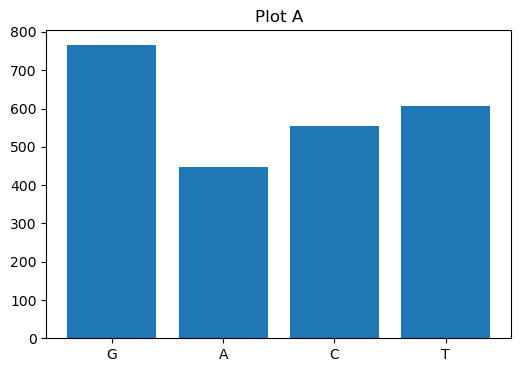

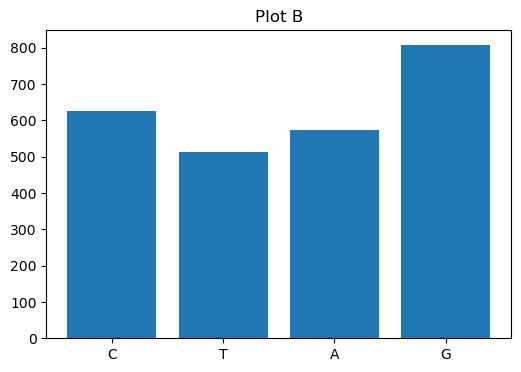

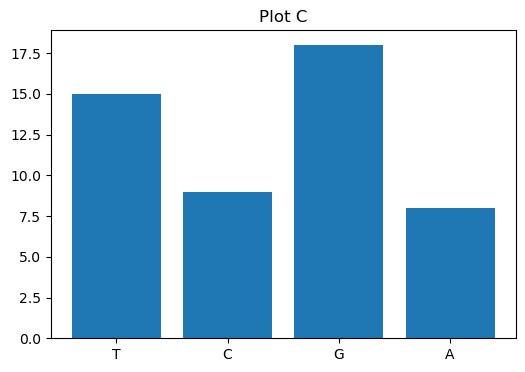

In [5]:
counters = [
    ("Plot A", Counter(SeqA)),
    ("Plot B", Counter(SeqB)),
    ("Plot C", Counter(SeqC)),
]

for title, counter in counters:
    plt.figure(figsize=(6, 4))
    plt.bar(counter.keys(), counter.values())
    plt.title(title)
    plt.show()



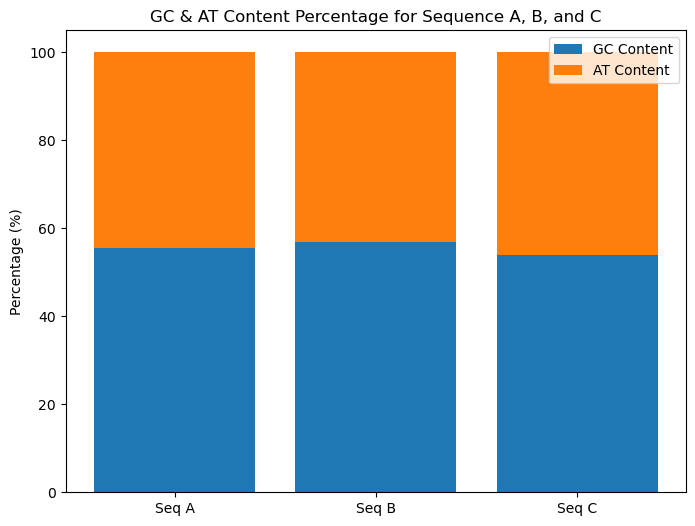

In [11]:
GC_seqA = gc_fraction(SeqA)*100
GC_seqB = gc_fraction(SeqB)*100
GC_seqC = gc_fraction(SeqC)*100

AT_seqA = 100 - GC_seqA
AT_seqB = 100 - GC_seqB
AT_seqC = 100 - GC_seqC

labels = ['Seq A', 'Seq B', 'Seq C']
gc_percentages = [GC_seqA, GC_seqB, GC_seqC]
at_percentages = [AT_seqA, AT_seqB, AT_seqC]

plt.figure(figsize=(8, 6))
plt.bar(labels, gc_percentages, label='GC Content')
plt.bar(labels, at_percentages, bottom=gc_percentages, label='AT Content')
plt.ylabel('Percentage (%)')
plt.title('GC & AT Content Percentage for Sequence A, B, and C')
plt.legend()
plt.show()

In [20]:
mtA = mt.Tm_Wallace(SeqA, strict=False)
mtB = mt.Tm_Wallace(SeqB, strict=False)
mtC = mt.Tm_Wallace(SeqC, strict=False)

mwA = mw(SeqA)
mwB = mw(SeqB)
mwC = mw(SeqC)

print(mtA, mtB, mtC)
print(mwA, mwB, mwC)

417.0 346.0 292.0
736731.8233000102 782875.8319000122 15614.9077


In [ ]:
SeqD = SeqA.seq[:100]
SeqE = SeqB.seq[:100]

seq1 = Seq('GCATGTAGCTAGCATCAGCTAC')
seq2 = Seq('ATGCTAGTCGATCATTATTAGC')


In [ ]:
seqA_transcribe = SeqA.seq.transcribe()
seqB_transcribe = SeqB.seq.transcribe()
seqC_transcribe = SeqC.seq.transcribe()
print(mtA)
print(mtB)
print(mtC)
seqA_translate = seqA_transcribe.translate()
seqB_translate = seqB_transcribe.translate()
seqC_translate = seqC_transcribe.translate()

In [9]:
SeqD = SeqA.seq[:100]
SeqE = SeqB.seq[:100]

seq1 = Seq('GCATGTAGCTAGCATCAGCTAC')
seq2 = Seq('ATGCTAGTCGATCATTATTAGC')

alignmentD = pairwise2.align.localxx(SeqD,seq1)
alignmentE = pairwise2.align.localxx(SeqE,seq2)

for align in alignmentD:
    print(format_alignment(*align))

for align in alignmentE:
    print(format_alignment(*align))

10 GTCCACTTCTTGCCTCTTGCGCGGTGCTGTGCGGTAAAAGAGGGGGCGTCGCGTTCGAGTAAAATTTTC-TCTTAAGCCTTAAGTGAGATAC
   |  ||                        |   ||     |         ||  |  ||         | ||   || |          |||
 1 G--CA------------------------T---GT-----A---------GC--T--AG---------CATC---AG-C----------TAC
  Score=21

9 GGTCCACTTCTTGCCTCTTGCGCGGTGCTGTGCGGTAAAAGAGGGGGCGTCGCGTTCGAGTAAAATTTTC-TCTTAAGCCTTAAGTGAGATAC
  |   ||                        |   ||     |         ||  |  ||         | ||   || |          |||
1 G---CA------------------------T---GT-----A---------GC--T--AG---------CATC---AG-C----------TAC
  Score=21

7 GTGGTCCACTTCTTGCCTCTTGCGCGGTGCTGTGCGGTAAAAGAGGGGGCGTCGCGTTCGAGTAAAATTTTC-TCTTAAGCCTTAAGTGAGATAC
  |     ||                        |   ||     |         ||  |  ||         | ||   || |          |||
1 G-----CA------------------------T---GT-----A---------GC--T--AG---------CATC---AG-C----------TAC
  Score=21

5 GTGTGGTCCACTTCTTGCCTCTTGCGCGGTGCTGTGCGGTAAAAGAGGGGGCGTCGCGTTCGAGTAAAATTTTC-TCTTAAGCCTTAAGTGA

In [14]:
distance(SeqD, SeqE)

60